# Clustering (K-Means)

Code in this notebook are adapted from: https://github.com/joanby/machinelearning-az



## Import Library







In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


## Import data from the data set






In [ ]:
# upload files from your local machine
from google.colab import files
#files.upload()
dataset = pd.read_excel("/content/dimensiones arboles finca las monjas.xlsx")
X = dataset.iloc[:, [1,2]].values


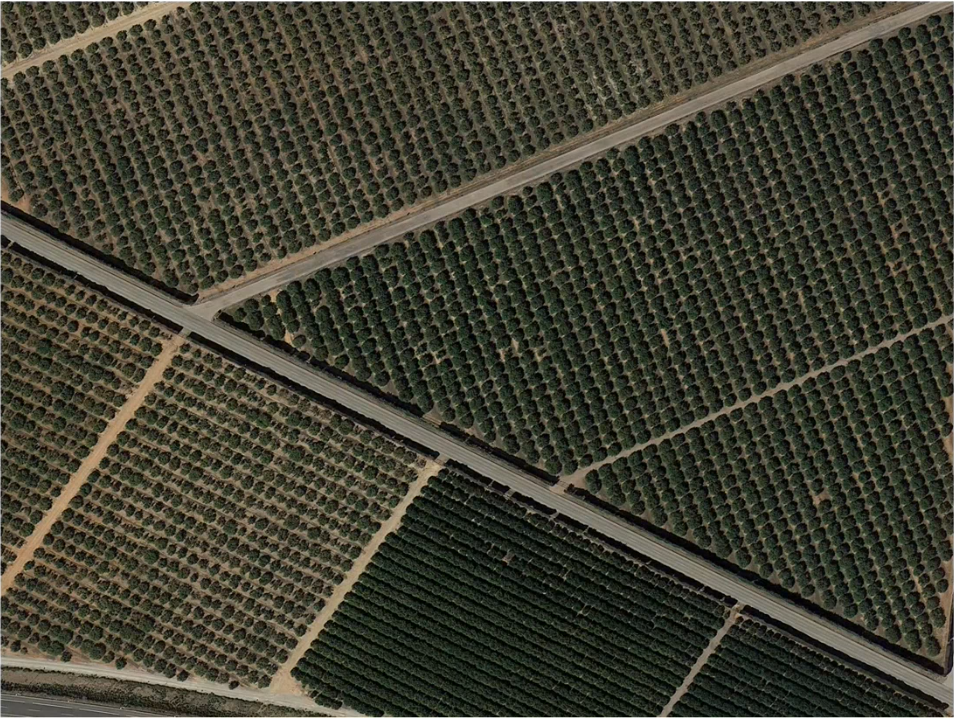

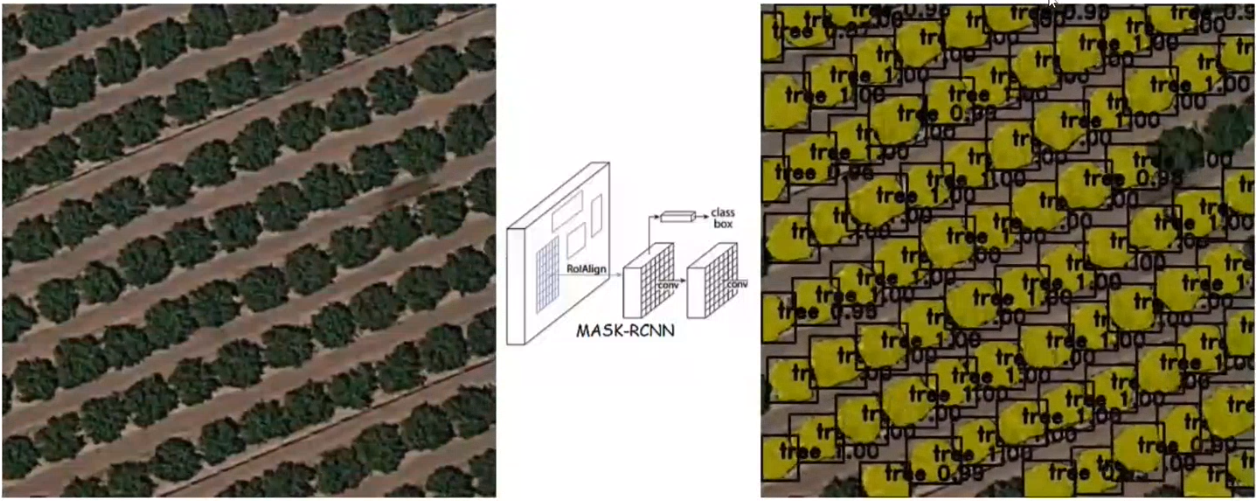

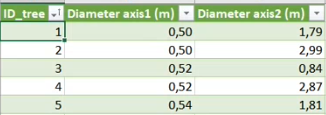

In [ ]:
# explore dataset
np.set_printoptions(formatter={'float': '{:0.2f}'.format})
print(X)
dataset.head(10)

[[0.50 1.79]
 [0.50 2.99]
 [0.52 0.84]
 [0.52 2.87]
 [0.54 1.81]
 [0.54 2.84]
 [0.56 0.84]
 [0.56 3.36]
 [0.58 0.76]
 [0.58 2.73]
 [0.58 1.07]
 [0.58 3.50]
 [0.60 1.10]
 [0.60 2.87]
 [0.60 1.04]
 [0.60 2.93]
 [0.62 1.67]
 [0.62 2.56]
 [0.66 1.50]
 [0.66 3.47]
 [0.68 1.67]
 [0.68 2.76]
 [0.70 0.81]
 [0.70 2.76]
 [0.77 1.07]
 [0.77 3.01]
 [0.77 1.59]
 [0.77 2.41]
 [0.79 1.56]
 [0.79 3.16]
 [0.81 0.79]
 [0.81 2.76]
 [0.87 0.79]
 [0.87 3.30]
 [0.87 1.07]
 [0.87 2.99]
 [0.89 1.16]
 [0.89 2.76]
 [0.95 1.41]
 [0.95 2.81]
 [0.97 1.67]
 [0.97 3.30]
 [0.99 1.70]
 [0.99 2.41]
 [0.99 1.47]
 [0.99 2.53]
 [1.01 2.24]
 [1.01 2.01]
 [1.01 1.87]
 [1.01 1.87]
 [1.05 2.16]
 [1.05 2.39]
 [1.07 2.21]
 [1.07 2.39]
 [1.07 1.96]
 [1.07 1.84]
 [1.09 2.10]
 [1.09 1.99]
 [1.14 2.13]
 [1.14 1.99]
 [1.14 2.27]
 [1.14 2.24]
 [1.16 2.16]
 [1.16 2.36]
 [1.18 2.13]
 [1.18 2.36]
 [1.18 2.10]
 [1.18 2.04]
 [1.18 2.36]
 [1.18 2.01]
 [1.20 2.24]
 [1.20 1.87]
 [1.22 2.07]
 [1.22 2.27]
 [1.30 2.01]
 [1.30 2.21]
 [1.30 2.19]

,ID_tree,Diameter axis1 (m),Diameter axis2 (m)
0,1,0.500000,1.785714
1,2,0.500000,2.985714
2,3,0.520492,0.842857
3,4,0.520492,2.871429
4,5,0.540984,1.814286
5,6,0.540984,2.842857
6,7,0.561475,0.842857
7,8,0.561475,3.357143
8,9,0.581967,0.757143
9,10,0.581967,2.728571


## Elbow method to find out the optimal number of clusters







Parametros:

- **init:**  
  Define el método que se utiliza para inicializar los centroides de los clústeres antes de comenzar el algoritmo.  
  - **"k-means++"** es una opción que mejora la selección inicial, eligiendo de manera inteligente los centroides para que estén lo más separados posible, lo que suele ayudar a conseguir una mejor convergencia y evitar malos resultados.

- **n_init:**  
  Es el número de veces que se ejecutará el algoritmo de *k-means* con diferentes inicializaciones de centroides.  
  - Por ejemplo, con `n_init=10`, el algoritmo se ejecuta 10 veces y se selecciona la solución que tenga el menor valor de WCSS (es decir, la mejor compacidad de los clústeres). Esto ayuda a evitar que el algoritmo se quede atrapado en un óptimo local.

- **max_iter:**  
  Indica el número máximo de iteraciones que se permitirán para cada ejecución del algoritmo de *k-means* hasta que se alcance la convergencia (cuando los centroides ya no cambian significativamente).  
  - En este caso, `max_iter=300` significa que cada ejecución del algoritmo puede iterar hasta 300 veces como máximo.

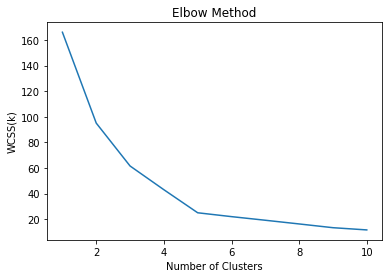

In [ ]:
#k-means++: Algoritmo que inicializa los centroides basado en la entropia de la información

#WCSS: Within-Cluster Sum of Squares. (suma de los cuadrados dentro del clúster)

#inertia_ = WCSS

# Create a KMeans object
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = "k-means++", n_init = 10, max_iter = 300, random_state = 0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS(k)")
plt.show()

## k-means method for segmenting the data set

In [ ]:
kmeans = KMeans(n_clusters = 5, init="k-means++", n_init = 10, max_iter = 300, random_state = 0)
y_kmeans = kmeans.fit_predict(X)
print(y_kmeans)
print(type(y_kmeans))
print(y_kmeans.shape)


[2 3 4 0 3 3 1 1 2 1 0 4 3 1 0 1 2 4 2 0 3 1 2 1 0 4 3 3 4 2 2 0 1 4 2 3 4
 1 0 4 1 0 2 4 3 0 1 0 4 1 0 4 3 0 1 2 2 1 2 0 4 0 3 2 1 0 0 1 2 0 1 0 4 0
 1 0 4 2 2 1 3 2 1 3 4 0 1 0 1 3 2 1 3 0 3 3 3 4 0 4 1 3 2 1 0 4 0 0 3 2 0
 2 2 0 2 1 2 3 1 2 2 0 4 2 4 0 1 4 1 3 1 0 0 4 1 3 1 0 3 2 4 4 2 0 0 1 4 1
 2 4 4 3 2 2 1 0 1 4 2 2 4 1 2 1 4 3 2 1 3 1 2 0 0 0 4 1 3 0 0 2 1 0 3 3 3
 2 0 1 0 0 0 2 2 1 4 0 3 4 2 3]
<class 'numpy.ndarray'>
(200,)


## Plotting the results of clustering







Lo que hace `y_kmeans == 0` es crear una **máscara booleana** que tiene el mismo tamaño que `y_kmeans`. Cada elemento de esta máscara es `True` si el correspondiente valor en `y_kmeans` es 0, y `False` en caso contrario.

Por ejemplo, si `y_kmeans` es:

```python
[2, 0, 1, 0, 3]
```

entonces:

```python
y_kmeans == 0
```

devuelve:

```python
[False, True, False, True, False]
```


- `X[y_kmeans == 0, 0]`: Selecciona todas las filas de `X` donde el cluster asignado es 0 (según el arreglo `y_kmeans`) y toma la primera columna de `X` para estas filas. Esto determina la coordenada \(x\) de los puntos en el gráfico.

- `X[y_kmeans == 0, 1]`: Similarmente, selecciona todas las filas de `X` donde el cluster asignado es 0 y toma la segunda columna de `X` para estas filas. Esto determina la coordenada \(y\) de los puntos en el gráfico.

- `s = 60`: Especifica el tamaño de los puntos en el gráfico. `s` es un parámetro opcional que controla el tamaño de los marcadores, en este caso, cada punto tendrá un tamaño de 60.



El atributo `cluster_centers_`proporciona la posición de los centroides de cada cluster.

- `kmeans.cluster_centers_[:, 0]`: Selecciona todas las filas del atributo `cluster_centers_` del objeto `kmeans` (que contiene los centroides de los clusters calculados por el algoritmo K-means) y toma la primera columna. Esto proporciona las coordenadas \(x\) de los centroides.

- `kmeans.cluster_centers_[:, 1]`: De manera similar, selecciona todas las filas de `cluster_centers_` y toma la segunda columna, proporcionando las coordenadas \(y\) de los centroides.



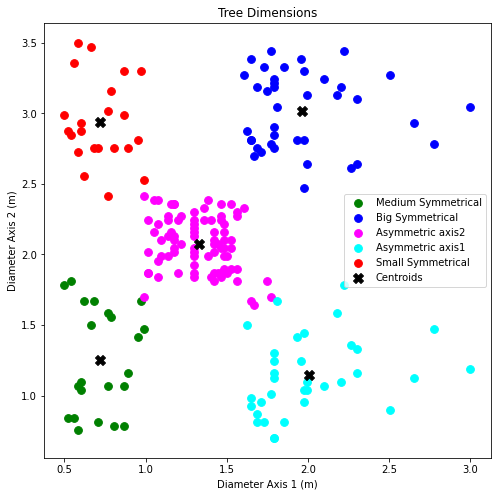

In [ ]:
# Plotting the training data results
plt.figure(figsize=(8,8))
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 60, c = "green", label = "Medium Symmetrical")
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 60, c = "blue", label = "Big Symmetrical")
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 60, c = "magenta", label = "Asymmetric axis2")
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 60, c = "cyan", label = "Asymmetric axis1")
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 60, c = "red", label = "Small Symmetrical")
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s = 100, marker='X', c = "black", label = "Centroids") # "cluster_centers_" este atributo nos da la posición del centro de los clusters.
plt.title("Tree Dimensions")
plt.xlabel("Diameter Axis 1 (m)")
plt.ylabel("Diameter Axis 2 (m)")
plt.legend()
plt.show()

**Resultados en función del tipo de deistancias:**
- Distancia euclidea: Los clusters tienen forma ovalada
- Distancia manhatan: Los clusters tienen forma rectangular


**Clasificación:**

Despues de haber obtenidos los clusters, y tenemos los datos etiquetados, podríamos usar un algoritmo de clasificación para dado un nuevo arbol que lo clasificque

## Number of trees included in each cluster.

In [ ]:
print ( "Number of trees included in the green cluster = %i" %len(X[y_kmeans == 0, 0]))
print ( "Number of trees included in the blue cluster = %i" %len(X[y_kmeans == 1, 0]))
print ( "Number of trees included in the magenta cluster = %i" %len(X[y_kmeans == 2, 0]))
print ( "Number of trees included in the cyan cluster = %i" %len(X[y_kmeans == 3, 0]))
print ( "Number of trees included in the red cluster = %i" %len(X[y_kmeans == 4, 0]))

Number of trees included in the green cluster = 22
Number of trees included in the blue cluster = 39
Number of trees included in the magenta cluster = 83
Number of trees included in the cyan cluster = 34
Number of trees included in the red cluster = 22


# **K-Means limitations**

### 1.  K-Means algorithm is limited to linear cluster boundaries.

That is, as points are assigned to the nearest cluster center, **KMeans algorithm is assuming that points will be closer to their own cluster center than to others**. This  assumption will get erroneous results for complex geometries, like in this example:



In [ ]:
from sklearn.datasets import make_moons
X, y = make_moons(200, noise=.05, random_state=0)

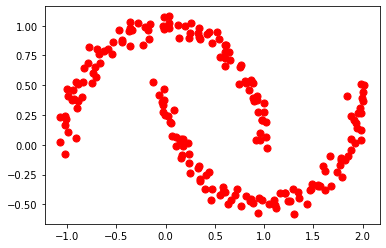

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c='red', s=50);

Let's compute KMeans for this dataset and verify how it fails:

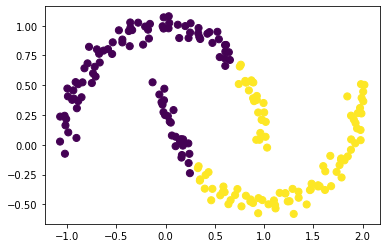

In [ ]:
# We can concatenate KMeans definition, fit and predict in a single line:
labels = KMeans(2, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

**SpectralClustering**:
- Hace una combinacion de dos cosas:
  - En vez de usar la distancia manhatan o euclidea, usa la distancia a sus vecinos
  - Tambien tiene en cuenta al centroide al que pertenece


Solution: ``SpectralClustering`` estimator uses the graph of nearest neighbors to compute a higher-dimensional representation of the data, and then assigns labels using a k-means algorithm:


/usr/local/lib/python3.7/dist-packages/sklearn/manifold/_spectral_embedding.py:261: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  "Graph is not fully connected, spectral embedding may not work as expected."


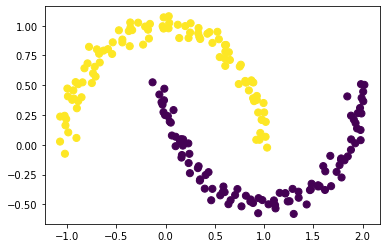

In [ ]:
from sklearn.cluster import SpectralClustering
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', assign_labels='kmeans')
labels = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

###2. K-Means is slow for big datasets

because each algorithm iteration must be run on every point in the dataset.